In [26]:
import pandas as pd
import scipy.stats as stats

pd.set_option('display.max_columns', None)

from sklearn.ensemble import RandomForestRegressor
import xgboost

import seaborn as sns
sns.set_style("whitegrid")

import matplotlib.pyplot as plt
from data_utils import colors_config
from model_utils import ModelSelector, train_test_split, set_seed, FPLDataPipe
import config


In [2]:
set_seed(77)
data = pd.read_parquet(config.FPL_DATA_PATH)

In [3]:
data.head()

,transfers_balance,position,gw,value,transfers_out,transfers_trend,code,kickoff_time,element,season,was_home,selected,name,transfers_in,opponent_team,total_points,bonus_ema_8,bps_ema_8,ict_index_ema_8,value_ema_8,threat_ema_8,transfers_balance_ema_8,transfers_in_ema_8,transfers_out_ema_8,transfers_trend_ema_8,xp_ema_8,assists_ema_8,clean_sheets_ema_8,creativity_ema_8,xa_ema_8,xg_involvements_ema_8,xg_conceded_ema_8,goals_conceded_ema_8,goals_scored_ema_8,minutes_ema_8,own_goals_ema_8,penalties_missed_ema_8,penalties_saved_ema_8,red_cards_ema_8,saves_ema_8,yellow_cards_ema_8,team_score_ema_8,opp_score_ema_8,score_diff_ema_8,xg_chain_ema_8,xg_buildup_ema_8,team_points_ema_8,opp_points_ema_8,team_xp_ema_8,opp_xp_ema_8,team_xg_ema_8,opp_xg_ema_8,team_np_xg_difference_ema_8,team_ppda_ema_8,opp_ppda_ema_8,team_deep_completions_ema_8,opp_deep_completions_ema_8,ppda_diff_ema_8,xa_per_90_ema_8,xg_involvements_per_90_ema_8,xg_per_90_ema_8,xg_conceded_per_90_ema_8,ict_index_per_90_ema_8,xg_chain_per_90_ema_8,xg_buildup_per_90_ema_8,team_xg_per_90_ema_8,opp_xg_per_90_ema_8,team_np_xg_difference_per_90_ema_8,bonus_lagged_1,bps_lagged_1,ict_index_lagged_1,influence_lagged_1,threat_lagged_1,transfers_balance_lagged_1,transfers_in_lagged_1,transfers_out_lagged_1,transfers_trend_lagged_1,xp_lagged_1,assists_lagged_1,clean_sheets_lagged_1,creativity_lagged_1,xa_lagged_1,xg_involvements_lagged_1,xg_lagged_1,xg_conceded_lagged_1,goals_conceded_lagged_1,goals_scored_lagged_1,minutes_lagged_1,own_goals_lagged_1,penalties_missed_lagged_1,penalties_saved_lagged_1,red_cards_lagged_1,saves_lagged_1,yellow_cards_lagged_1,team_score_lagged_1,opp_score_lagged_1,score_diff_lagged_1,shots_lagged_1,xg_chain_lagged_1,xg_buildup_lagged_1,team_points_lagged_1,opp_points_lagged_1,team_xp_lagged_1,opp_xp_lagged_1,team_xg_lagged_1,opp_xg_lagged_1,team_np_xg_difference_lagged_1,team_ppda_lagged_1,opp_ppda_lagged_1,team_deep_completions_lagged_1,opp_deep_completions_lagged_1,ppda_diff_lagged_1,xa_per_90_lagged_1,xg_involvements_per_90_lagged_1,xg_per_90_lagged_1,xg_conceded_per_90_lagged_1,ict_index_per_90_lagged_1,xg_chain_per_90_lagged_1,xg_buildup_per_90_lagged_1,team_xg_per_90_lagged_1,opp_xg_per_90_lagged_1,team_np_xg_difference_per_90_lagged_1,xg_share_lagged_1
0,0.0,GK,32.0,4.0,0.0,0.000000,11948.0,2023-04-22T14:00:00Z,760.0,2223.0,False,0.0,Andy Lonergan,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17.0,GK,33.0,4.0,1.0,0.515152,11948.0,2023-04-27T18:45:00Z,760.0,2223.0,True,33.0,Andy Lonergan,18.0,15.0,0.0,0.0,0.0,0.0,4.0,0.0,0.000000,0.000000,0.000000,0.000000,1.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,1.000000,1.000000,1.307300,1.177100,0.433712,0.368137,0.065575,8.818182,9.437500,3.000000,5.000000,-0.619318,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.3073,1.1771,0.433712,0.368137,0.065575,8.818182,9.437500,3.0,5.0,-0.619318,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,19.0,GK,34.0,4.0,6.0,0.226190,11948.0,2023-05-01T19:00:00Z,760.0,2223.0,False,84.0,Andy Lonergan,25.0,10.0,0.0,0.0,0.0,0.0,4.0,0.0,3.777778,4.000000,0.222222,0.114478,1.055556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.222222,0.888889,-0.666667,0.0,0.0,0.777778,1.444444,1.056344,1.522144,0.510000,0.922702,-0.412702,9.383838,9.340278,3.666667,5.8888

In [4]:
data.season.unique()

array([2223., 2324., 2425., 2526.])

In [5]:
data.shape

(105856, 123)

In [6]:
cols_map = colors_config.FEATURES_GROUP
cols_map.keys()

dict_keys(['target', 'id_cols', 'static_cols', 'fpl_cols', 'perf_cols', 'pre_game_cols'])

In [7]:
num_cols = [c for c in data.columns if "ema" in c or "lagg" in c]
len(num_cols)

107

In [8]:
static_cols = [f"{c}_id" for c in cols_map["static_cols"] if c not in  ["was_home", "team_strength", "player_id"]] + ["was_home", "team_strength"]

In [9]:
fpl_data_pipe = FPLDataPipe(num_cols=num_cols,
                            cat_cols=[c for c in cols_map.get("static_cols") if c in data.columns])

data_splits = train_test_split(data)

X_train = fpl_data_pipe.preprocessor.fit_transform(data_splits["X_train"])
X_valid = fpl_data_pipe.preprocessor.transform(data_splits["X_valid"])
X_test = fpl_data_pipe.preprocessor.transform(data_splits["X_test"])

y_train, y_valid, y_test = data_splits["y_train"], data_splits["y_valid"], data_splits["y_test"]

In [10]:
X_train.shape, y_train.shape, X_valid.shape, y_valid.shape, X_test.shape, y_test.shape

((56230, 111), (56230,), (27283, 111), (27283,), (22343, 111), (22343,))

In [33]:
type(X_train)

pandas.core.frame.DataFrame

In [11]:
X_train.head()

,num__bonus_ema_8,num__bps_ema_8,num__ict_index_ema_8,num__value_ema_8,num__threat_ema_8,num__transfers_balance_ema_8,num__transfers_in_ema_8,num__transfers_out_ema_8,num__transfers_trend_ema_8,num__xp_ema_8,num__assists_ema_8,num__clean_sheets_ema_8,num__creativity_ema_8,num__xa_ema_8,num__xg_involvements_ema_8,num__xg_conceded_ema_8,num__goals_conceded_ema_8,num__goals_scored_ema_8,num__minutes_ema_8,num__own_goals_ema_8,num__penalties_missed_ema_8,num__penalties_saved_ema_8,num__red_cards_ema_8,num__saves_ema_8,num__yellow_cards_ema_8,num__team_score_ema_8,num__opp_score_ema_8,num__score_diff_ema_8,num__xg_chain_ema_8,num__xg_buildup_ema_8,num__team_points_ema_8,num__opp_points_ema_8,num__team_xp_ema_8,num__opp_xp_ema_8,num__team_xg_ema_8,num__opp_xg_ema_8,num__team_np_xg_difference_ema_8,num__team_ppda_ema_8,num__opp_ppda_ema_8,num__team_deep_completions_ema_8,num__opp_deep_completions_ema_8,num__ppda_diff_ema_8,num__xa_per_90_ema_8,num__xg_involvements_per_90_ema_8,num__xg_per_90_ema_8,num__xg_conceded_per_90_ema_8,num__ict_index_per_90_ema_8,num__xg_chain_per_90_ema_8,num__xg_buildup_per_90_ema_8,num__team_xg_per_90_ema_8,num__opp_xg_per_90_ema_8,num__team_np_xg_difference_per_90_ema_8,num__bonus_lagged_1,num__bps_lagged_1,num__ict_index_lagged_1,num__influence_lagged_1,num__threat_lagged_1,num__transfers_balance_lagged_1,num__transfers_in_lagged_1,num__transfers_out_lagged_1,num__transfers_trend_lagged_1,num__xp_lagged_1,num__assists_lagged_1,num__clean_sheets_lagged_1,num__creativity_lagged_1,num__xa_lagged_1,num__xg_involvements_lagged_1,num__xg_lagged_1,num__xg_conceded_lagged_1,num__goals_conceded_lagged_1,num__goals_scored_lagged_1,num__minutes_lagged_1,num__own_goals_lagged_1,num__penalties_missed_lagged_1,num__penalties_saved_lagged_1,num__red_cards_lagged_1,num__saves_lagged_1,num__yellow_cards_lagged_1,num__team_score_lagged_1,num__opp_score_lagged_1,num__score_diff_lagged_1,num__shots_lagged_1,num__xg_chain_lagged_1,num__xg_buildup_lagged_1,num__team_points_lagged_1,num__opp_points_lagged_1,num__team_xp_lagged_1,num__opp_xp_lagged_1,num__team_xg_lagged_1,num__opp_xg_lagged_1,num__team_np_xg_difference_lagged_1,num__team_ppda_lagged_1,num__opp_ppda_lagged_1,num__team_deep_completions_lagged_1,num__opp_deep_completions_lagged_1,num__ppda_diff_lagged_1,num__xa_per_90_lagged_1,num__xg_involvements_per_90_lagged_1,num__xg_per_90_lagged_1,num__xg_conceded_per_90_lagged_1,num__ict_index_per_90_lagged_1,num__xg_chain_per_90_lagged_1,num__xg_buildup_per_90_lagged_1,num__team_xg_per_90_lagged_1,num__opp_xg_per_90_lagged_1,num__team_np_xg_difference_per_90_lagged_1,num__xg_share_lagged_1,col__position_FWD,col__position_GK,col__position_MID,col__was_home_1.0
0,0.0,0.094923,0.0,0.000000,0.0,0.528924,0.000000,0.000000e+00,0.370404,0.067330,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.600000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.605660,0.000000,0.000000,0.000000,0.000000,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.424238,0.0,0.170732,0.0,0.0,0.0,0.616689,0.000000,0.000000e+00,0.704715,0.112782,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.500000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.45633,0.0,0.0,1.0,0.0,0.0
1,0.0,0.094923,0.0,0.279392,0.0,0.528924,0.000000,0.000000e+00,0.370404,0.164446,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.600000,0.0,0.0,0.333333,0.333333,0.439931,0.392773,0.088111,0.075743,0.614147,0.045690,0.048899,0.111111,0.135135,0.498345,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.424238,0.0,0.170732,0.0,0.0,0.0,0.616689,0.000000,0.000000e+00,0.704715,0.169173,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.500000,0.0,0.0,0.0,0.333333,0.333333,0.436217,0.392773,0.065010,0.055180,0.507007,0.045690,0.048899,0.081081,0.135135,0.498

In [12]:
xgb = xgboost.XGBRegressor(random_state=77, objective='reg:squarederror', eval_metric='rmse')
rf = RandomForestRegressor(random_state=77)

In [13]:
param_grid = [
    {
        "n_estimators": stats.randint(100, 500),
        "max_depth": stats.randint(4, 8),
        "min_samples_split": stats.randint(10, 40),
        "min_samples_leaf": stats.randint(2, 15)
    },
    {
        "n_estimators": stats.randint(100, 500),
        "max_depth": stats.randint(2, 5),
        "learning_rate": stats.uniform(0.005, 0.05),
        "reg_alpha": stats.uniform(0.1, 10.0),
        "reg_lambda": stats.uniform(0.1, 10.0),
        "colsample_bytree": stats.uniform(0.5, 0.4),
        "subsample": stats.uniform(0.6, 0.3)
    }
]

In [14]:
model = [rf, xgb]
model_names = ["rf", "xgb"]


In [15]:
selector = ModelSelector(random_state=77)

In [16]:
results, best_params = selector.params_search(models=model,
                       models_names=model_names,
                       params_grid=param_grid,
                       X_train=X_train,
                       y_train=y_train,
                       cv=5,
                       n_iter=5,
                       scoring="neg_mean_squared_error")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits


In [17]:
results

,data,name,cv_mean_neg_mean_squared_error,best_params,mse,mae,r2
1,train,xgb,-3.599641,"{'colsample_bytree': 0.7988109226828486, 'lear...",3.446590,0.955201,0.361766
0,train,rf,-3.644891,"{'max_depth': 7, 'min_samples_leaf': 12, 'min_...",3.449909,0.954217,0.361151


In [18]:
eval_results, y_preds = selector.evaluate(best_params, X_valid, y_valid)

In [19]:
eval_results

,data,model_name,mse,mae,r2
0,test,rf,3.695112,1.005056,0.307933
1,test,xgb,3.693481,1.008014,0.308239


In [27]:
trained_models = {c: best_params.get(c) for c in model_names}

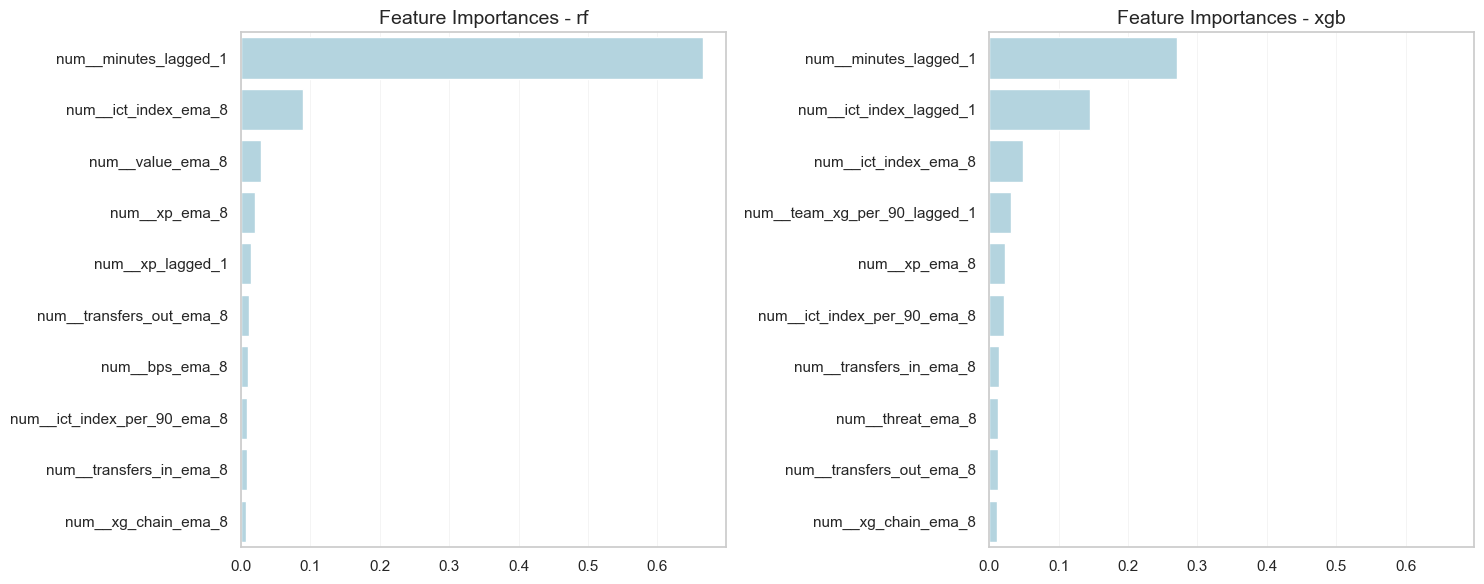

In [47]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, 6), sharex=True)

for idx, (model_name, model) in enumerate(trained_models.items()):
    sns.barplot(data=pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10), ax=ax[idx], orient="h", color="lightblue")
    ax[idx].set_title(f"Feature Importances - {model_name}", fontsize=14)
plt.tight_layout()

In [71]:
preds = {}
for model_name, model in trained_models.items():
    preds[model_name] = model.predict(X_test)

preds = pd.DataFrame(preds, index=X_test.index)
final_results = pd.concat([data.loc[X_test.index, ["name", "season", "total_points", "gw"]], preds], axis=1)

In [72]:
final_results.sample(10)

,name,season,total_points,gw,rf,xgb
96987,Milos Kerkez,2526.0,2.0,17.0,2.593024,2.646806
71702,Giorgi Mamardashvili,2526.0,0.0,20.0,0.306986,0.298809
100734,Claudio Echeverri,2526.0,0.0,4.0,0.039345,0.087278
63920,Steven Benda,2526.0,0.0,8.0,0.034408,0.044319
67196,Cheick Doucouré,2526.0,0.0,15.0,0.037970,0.049386
104168,Lucá Williams-Barnett,2526.0,0.0,24.0,0.043412,0.047467
99042,Takai Kōta,2526.0,0.0,18.0,0.042522,0.023763
78266,Gabriel Słonina,2526.0,0.0,9.0,0.049776,0.084186
103701,Ben Winterburn,2526.0,0.0,14.0,0.050980,0.048841
40285,Olivier Boscagli,2526.0,0.0,20.0,0.382815,0.358399


In [73]:
final_results[final_results.name=="Erling Haaland"]

,name,season,total_points,gw,rf,xgb
51345,Erling Haaland,2526.0,13.0,1.0,1.388722,1.039023
51346,Erling Haaland,2526.0,2.0,2.0,5.979013,5.237172
51347,Erling Haaland,2526.0,9.0,3.0,5.908618,5.202808
51348,Erling Haaland,2526.0,13.0,4.0,6.437063,6.445973
51349,Erling Haaland,2526.0,9.0,5.0,6.014207,5.130260
51350,Erling Haaland,2526.0,16.0,6.0,6.781929,6.364880
51351,Erling Haaland,2526.0,8.0,7.0,6.361313,4.834560
51352,Erling Haaland,2526.0,13.0,8.0,6.635833,6.435110
51353,Erling Haaland,2526.0,2.0,9.0,7.057023,5.936971
51354,Erling Haaland,2526.0,13.0,10.0,6.814220,6.858572


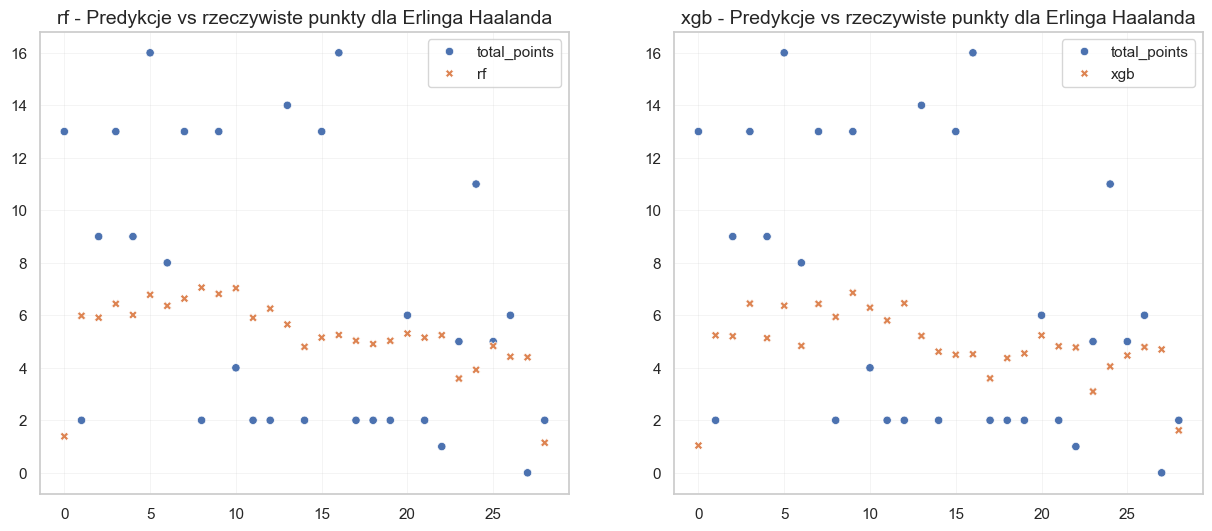

In [77]:

fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(15, 6), sharex=True)
for model_name in model_names:
    sns.scatterplot(data=final_results.loc[final_results.name=="Erling Haaland", ["total_points", model_name]].reset_index(drop=True), ax=ax[model_names.index(model_name)], color="steelblue")
    ax[model_names.index(model_name)].set_title(f"{model_name} - Predykcje vs rzeczywiste punkty dla Erlinga Haalanda", fontsize=14);



In [80]:
final_results.loc[final_results.xgb==final_results.xgb.max()]

,name,season,total_points,gw,rf,xgb
51354,Erling Haaland,2526.0,13.0,10.0,6.81422,6.858572


In [81]:
final_results.loc[final_results.rf==final_results.rf.max()]

,name,season,total_points,gw,rf,xgb
51353,Erling Haaland,2526.0,2.0,9.0,7.057023,5.936971
